In [29]:
import datetime, calendar, glob, os, requests, pickle

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

path_to_maps = "/Users/Guille/Desktop/wecc_model/input_data/geography/maps/"

0                              Puget Sound Energy, Inc.
1                            PUD No. 1 of Chelan County
2                           PUD No. 1 of Douglas County
3                             PUD No. 2 of Grant County
4                                    Seattle City Light
5        City of Tacoma, Department of Public Utilities
6                                    Avista Corporation
7                                       PacifiCorp West
8          Bonneville power Administration-Transmission
9                     Portland General Electric Company
10                                  Idaho Power Company
11           Balancing Authority of Northern California
12                          Turlock Irrigation District
13            Los Angeles Department of Water and Power
14                         Imperial Irrigation District
15               California Independent System operator
16                                 Nevada Power Company
17                                  NorthWestern

<Axes: >

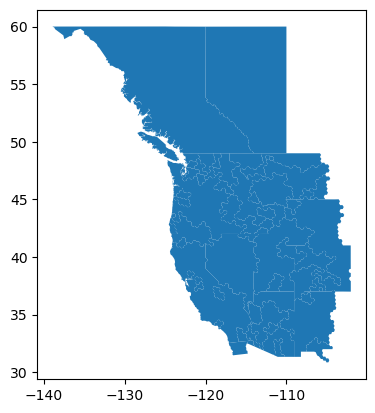

In [228]:
# Load
WECC_ = gpd.read_file(path_to_maps + "/WECC/WECC.shp")
print(WECC_['BA_Name'])
WECC_.plot()

<Axes: >

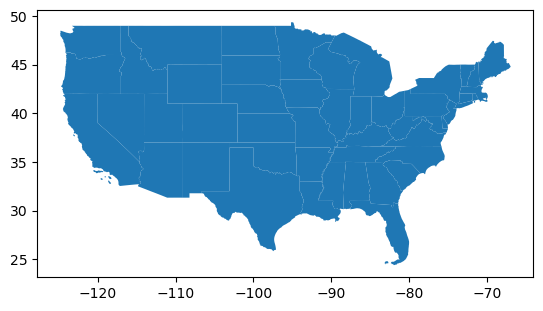

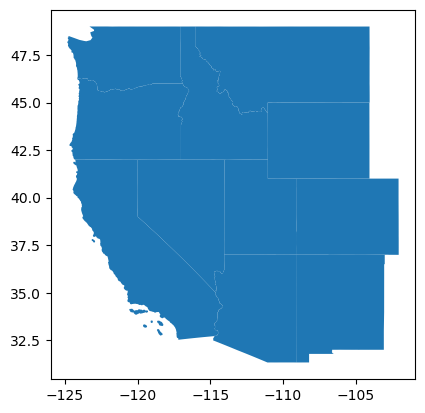

In [190]:
US_ = gpd.read_file(path_to_maps + "/US/tl_2022_us_state.shp")

# Remove non-continental states/territories
exclude = ['02', '15', '60', '66', '69', '72', '78']

CONUS_ = US_[~US_['STATEFP'].isin(exclude)]
CONUS_.plot()

WESTERNUS_ = CONUS_[CONUS_['REGION'] == '4']
WESTERNUS_.plot()


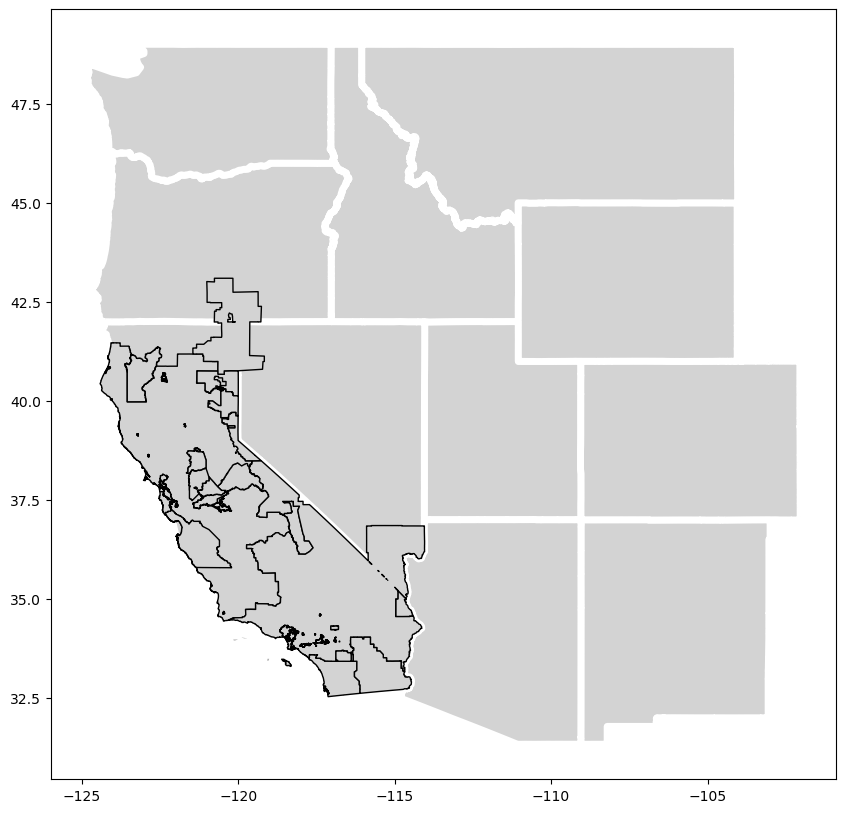

In [226]:
CAISO_ = gpd.read_file(path_to_maps + "/CAISO/Balancing_Authority_Areas_in_CA.shp")
# CAISO_ = CAISO_.drop(index=[4, 8]).reset_index(drop = True)
# print(CAISO_)
CAISO_ = gpd.read_file(path_to_maps + "/CAISO/California_Electric_Utility_Service_Territory.shp")
# CAISO_ = CAISO_.drop(index=[
#     1, 3, 4, 6, 9, 11, 12, 13, 15, 16, 17, 20, 21, 22, 25, 31, 32, 34, 35, 36, 37, 38, 42, 
#     43, 44, 48, 49, 50, 53,
#     ])#.reset_index(drop = True)

CAISO_ = CAISO_.drop(index=[11,
    ])#.reset_index(drop = True)

# CAISO_ = CAISO_.loc[[5, 8, 10, 18, 19, 23, 27, 30, 51]]
# print(CAISO_)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

WESTERNUS_.plot(
    ax=ax,
    edgecolor="w",
    color="lightgray",
    linewidth=5
)

CAISO_.plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightgray"
)

plt.show()

<StringArray>
[                                 'KINGS RIVER CONSERVATION DIST',
                                                  'CITY OF AZUSA',
                              'LASSEN MUNICIPAL UTILITY DISTRICT',
                                            'CITY OF LODI - (CA)',
                                          'CITY OF LOMPOC - (CA)',
                        'LOS ANGELES DEPARTMENT OF WATER & POWER',
                                         'CITY OF BANNING - (CA)',
                                     'MERCED IRRIGATION DISTRICT',
                                    'MODESTO IRRIGATION DISTRICT',
                                         'CITY OF NEEDLES - (CA)',
                                     'PACIFIC GAS & ELECTRIC CO.',
                                       'CITY OF PALO ALTO - (CA)',
                                        'CITY OF PASADENA - (CA)',
                                  'PLUMAS-SIERRA RURAL ELEC COOP',
                                         'CITY O

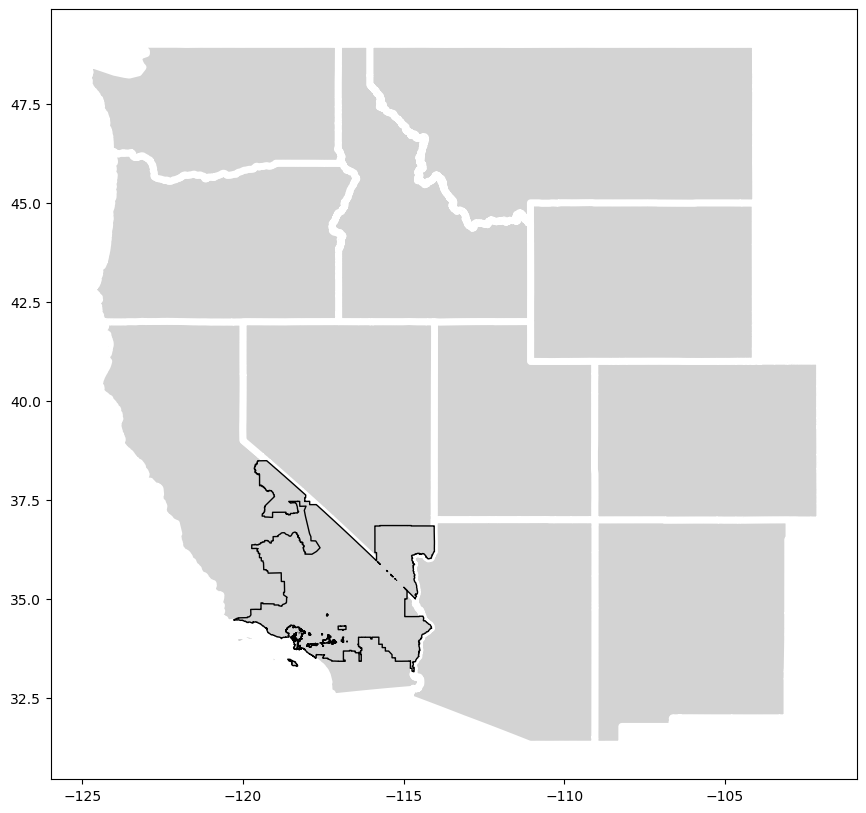

In [75]:
#CAISO_ = gpd.read_file(path_to_maps + "/CAISO/Balancing_Authority_Areas_in_CA.shp")
CAISO_ = gpd.read_file(path_to_maps + "/CAISO/California_Electric_Utility_Service_Territory.shp")
CAISO_ = CAISO_.drop(index=11)
print(CAISO_['NAME'].unique())
# Plot
fig, ax = plt.subplots(figsize=(12, 10))

WESTERNUS_.plot(
    ax=ax,
    edgecolor="w",
    color="lightgray",
    linewidth=5
)

CAISO_.loc[CAISO_['NAME'] == 'SOUTHERN CALIFORNIA EDISON CO'].plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightgray"
)

plt.show()

                        name load_zone    ba  \
0    PacifiCorp (East Idaho)      PAID  PACE   
1     PacifiCorp (East Utah)      PAUT  PACE   
2  PacifiCorp (East Wyoming)      PAWY  PACE   
3          PacifiCorp (West)      PACW  PACE   

                                            geometry  
0  MULTIPOLYGON (((-112.68582 42.11697, -112.6858...  
1  MULTIPOLYGON (((-113.52903 37.13829, -113.5283...  
2  MULTIPOLYGON (((-105.27663 41.30122, -105.2766...  
3  MULTIPOLYGON (((-114.05005 37, -114.05005 37.0...  


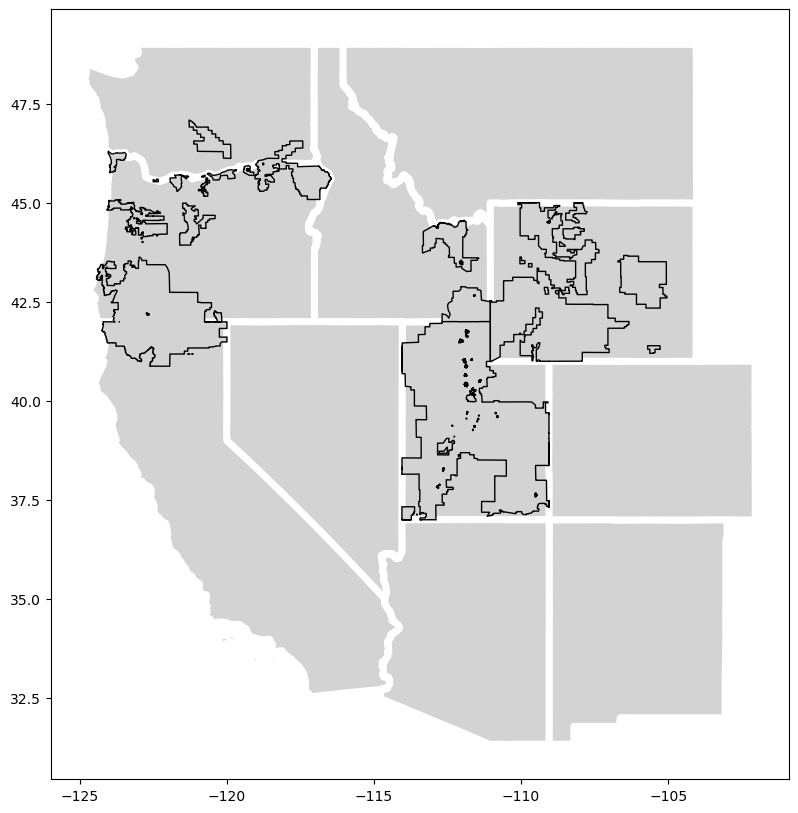

In [188]:
PACE_ = gpd.read_file(path_to_maps + "PACE/PACE.shp")
print(PACE_)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

WESTERNUS_.plot(
    ax=ax,
    edgecolor="w",
    color="lightgray",
    linewidth=5
)

PACE_.plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightgray"
)

plt.show()

                            name load_zone    ba  \
0     Idaho Power (Magic Valley)      IPMV  IPCO   
1         Idaho Power (Far East)      IPFE  IPCO   
2  Idaho Power (Treasour Valley)      IPTV  IPCO   

                                            geometry  
0  POLYGON ((-115.77149 43.82488, -115.7958 43.79...  
1  MULTIPOLYGON (((-112.54073 43.41765, -112.4947...  
2  POLYGON ((-116.51316 43.68362, -116.51241 43.6...  


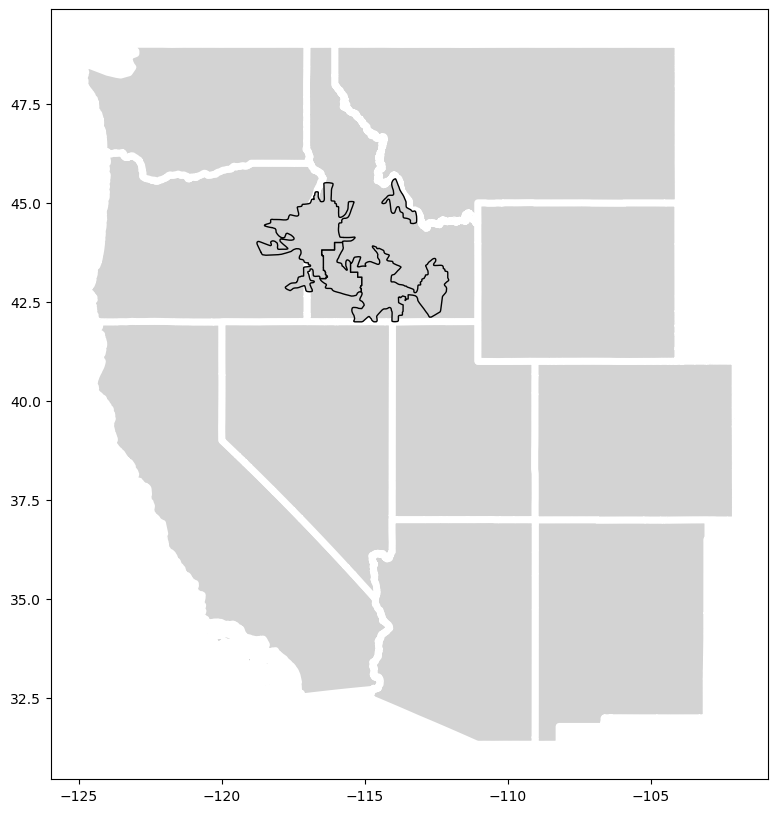

In [135]:
IPCO_ = gpd.read_file(path_to_maps + "/IPCO/IPCO.shp")
print(IPCO_)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

WESTERNUS_.plot(
    ax=ax,
    edgecolor="w",
    color="lightgray",
    linewidth=5
)

IPCO_.plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightgray"
)

plt.show()

                   name load_zone    ba  \
0          Nevada Power      NEVP  NEVP   
1  Sierra Pacific Power      SPPC  NEVP   

                                            geometry  
0  POLYGON ((-114.71077 36.15891, -114.71069 36.1...  
1  MULTIPOLYGON (((-117.28616 41.47043, -117.2286...  


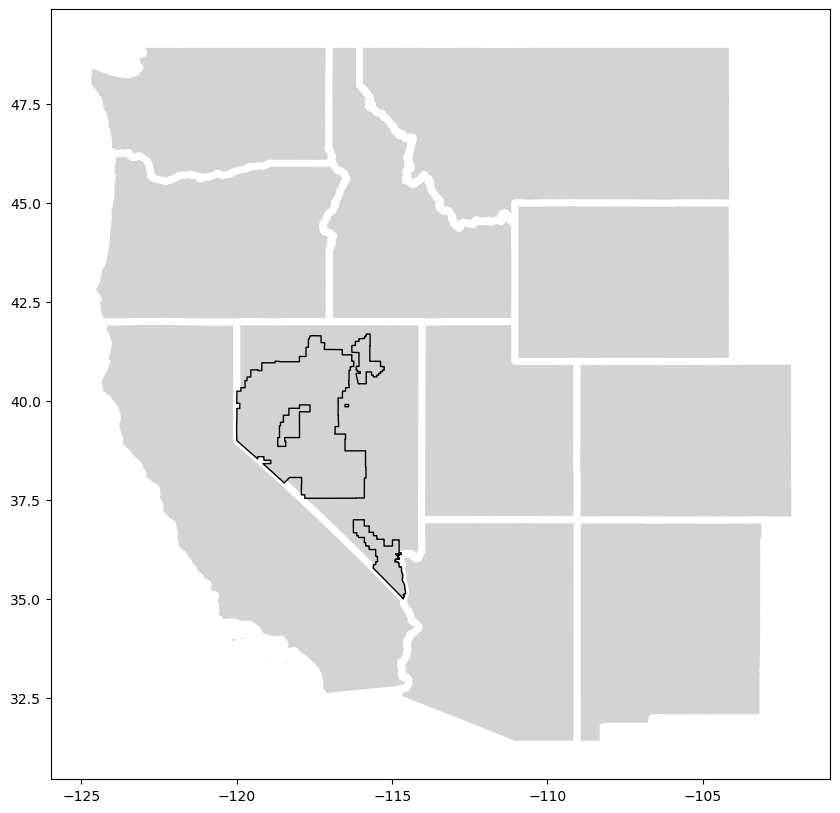

In [137]:
NEVP_ = gpd.read_file(path_to_maps + "/NEVP/NEVP.shp")
print(NEVP_)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

WESTERNUS_.plot(
    ax=ax,
    edgecolor="w",
    color="lightgray",
    linewidth=5
)

NEVP_.plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightgray"
)

plt.show()
